# Импорты

In [1]:
import pandas
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Загрузка

In [2]:
df = pandas.read_csv('diabetes.csv')
df

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,699995,29,1,59,6.9,5.2,1.5,26.1,0.88,133,...,Female,Hispanic,Postgraduate,Upper-Middle,Former,Employed,0,0,0,0.0
699996,699996,46,2,72,7.7,7.7,3.8,25.5,0.85,106,...,Female,Hispanic,Graduate,Upper-Middle,Former,Employed,0,0,1,1.0
699997,699997,35,1,50,5.6,6.1,6.4,26.9,0.88,127,...,Female,White,Graduate,Middle,Never,Employed,0,0,0,1.0
699998,699998,49,2,70,5.7,6.9,4.7,25.2,0.86,116,...,Female,White,Highschool,Lower-Middle,Never,Retired,0,0,0,1.0


# Обработка

## Удаление id

In [3]:
df = df.drop('id', axis=1)
df

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,29,1,59,6.9,5.2,1.5,26.1,0.88,133,57,...,Female,Hispanic,Postgraduate,Upper-Middle,Former,Employed,0,0,0,0.0
699996,46,2,72,7.7,7.7,3.8,25.5,0.85,106,85,...,Female,Hispanic,Graduate,Upper-Middle,Former,Employed,0,0,1,1.0
699997,35,1,50,5.6,6.1,6.4,26.9,0.88,127,84,...,Female,White,Graduate,Middle,Never,Employed,0,0,0,1.0
699998,49,2,70,5.7,6.9,4.7,25.2,0.86,116,67,...,Female,White,Highschool,Lower-Middle,Never,Retired,0,0,0,1.0


## Обработка пропусков

In [4]:
df.isna().sum()

age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
diagnosed_diabetes                    0


## Обработка категориальных признаков

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 25 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 700000 non-null  int64  
 1   alcohol_consumption_per_week        700000 non-null  int64  
 2   physical_activity_minutes_per_week  700000 non-null  int64  
 3   diet_score                          700000 non-null  float64
 4   sleep_hours_per_day                 700000 non-null  float64
 5   screen_time_hours_per_day           700000 non-null  float64
 6   bmi                                 700000 non-null  float64
 7   waist_to_hip_ratio                  700000 non-null  float64
 8   systolic_bp                         700000 non-null  int64  
 9   diastolic_bp                        700000 non-null  int64  
 10  heart_rate                          700000 non-null  int64  
 11  cholesterol_total         

### Label encoding

In [6]:
df["gender"].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [7]:
df["income_level"].unique()

array(['Lower-Middle', 'Upper-Middle', 'Low', 'Middle', 'High'],
      dtype=object)

In [8]:
df["smoking_status"].unique()

array(['Current', 'Never', 'Former'], dtype=object)

In [9]:
df["gender"] = df["gender"].map({"Male": 1, "Female": 0, "Other": 2})
df["income_level"] = df["income_level"].map({"Low": 1, "Lower-Middle": 2, "Middle": 3, "Upper-Middle": 4, "High": 5})
df["smoking_status"] = df["smoking_status"].map({"Never": 0, "Former": 1, "Current": 2})
df

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,0,Hispanic,Highschool,2,2,Employed,0,0,0,1.0
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,0,White,Highschool,4,0,Employed,0,0,0,1.0
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,1,Hispanic,Highschool,2,0,Retired,0,0,0,0.0
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,0,White,Highschool,2,2,Employed,0,1,0,1.0
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,1,White,Highschool,4,0,Retired,0,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,29,1,59,6.9,5.2,1.5,26.1,0.88,133,57,...,0,Hispanic,Postgraduate,4,1,Employed,0,0,0,0.0
699996,46,2,72,7.7,7.7,3.8,25.5,0.85,106,85,...,0,Hispanic,Graduate,4,1,Employed,0,0,1,1.0
699997,35,1,50,5.6,6.1,6.4,26.9,0.88,127,84,...,0,White,Graduate,3,0,Employed,0,0,0,1.0
699998,49,2,70,5.7,6.9,4.7,25.2,0.86,116,67,...,0,White,Highschool,2,0,Retired,0,0,0,1.0


### One hot encoding

In [10]:
df["ethnicity"].unique()

array(['Hispanic', 'White', 'Asian', 'Black', 'Other'], dtype=object)

In [11]:
df["education_level"].unique()

array(['Highschool', 'Graduate', 'Postgraduate', 'No formal'],
      dtype=object)

In [12]:
df["employment_status"].unique()

array(['Employed', 'Retired', 'Student', 'Unemployed'], dtype=object)

In [13]:
df = pandas.get_dummies(
    df,
    columns=["ethnicity", "education_level", "employment_status"],
    drop_first=True,
    dtype=int
)
df

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,education_level_Highschool,education_level_No formal,education_level_Postgraduate,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,...,0,1,0,0,1,0,0,0,0,0
1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,...,0,0,0,1,1,0,0,0,0,0
2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,...,0,1,0,0,1,0,0,1,0,0
3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,...,0,0,0,1,1,0,0,0,0,0
4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,...,0,0,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,29,1,59,6.9,5.2,1.5,26.1,0.88,133,57,...,0,1,0,0,0,0,1,0,0,0
699996,46,2,72,7.7,7.7,3.8,25.5,0.85,106,85,...,0,1,0,0,0,0,0,0,0,0
699997,35,1,50,5.6,6.1,6.4,26.9,0.88,127,84,...,0,0,0,1,0,0,0,0,0,0
699998,49,2,70,5.7,6.9,4.7,25.2,0.86,116,67,...,0,0,0,1,1,0,0,1,0,0


## Целевая переменная

In [14]:
Y = df["diagnosed_diabetes"]
df = df.drop("diagnosed_diabetes", axis=1)
Y

0         1.0
1         1.0
2         0.0
3         1.0
4         1.0
         ... 
699995    0.0
699996    1.0
699997    1.0
699998    1.0
699999    1.0
Name: diagnosed_diabetes, Length: 700000, dtype: float64

## Нормализация

In [15]:
df = (df - df.min()) / (df.max() - df.min())
df

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,...,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,education_level_Highschool,education_level_No formal,education_level_Postgraduate,employment_status_Retired,employment_status_Student,employment_status_Unemployed
0,0.171429,0.000,0.058981,0.775510,0.544118,0.345912,0.785408,0.675676,0.291667,0.358491,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.442857,0.125,0.096515,0.571429,0.500000,0.327044,0.373391,0.405405,0.402778,0.490566,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.185714,0.250,0.210456,0.857143,0.632353,0.534591,0.386266,0.405405,0.055556,0.716981,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.500000,0.250,0.101877,0.459184,0.573529,0.540881,0.493562,0.405405,0.416667,0.339623,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.500000,0.000,0.072386,0.571429,0.455882,0.283019,0.587983,0.594595,0.236111,0.169811,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,0.142857,0.000,0.077748,0.693878,0.308824,0.056604,0.472103,0.540541,0.583333,0.113208,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
699996,0.385714,0.125,0.095174,0.775510,0.676471,0.201258,0.446352,0.459459,0.208333,0.641509,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
699997,0.228571,0.000,0.065684,0.561224,0.441176,0.364780,0.506438,0.540541,0.500000,0.622642,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
699998,0.428571,0.125,0.092493,0.571429,0.558824,0.257862,0.433476,0.486486,0.347222,0.301887,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


# Обучение модели

## Разбиение на тренировочную и тестовую

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(df, Y, test_size=0.3, random_state=42)

## Обучение модели XGBClassifier

In [17]:
model = XGBClassifier(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    Y_train,
    eval_set=[(X_test, Y_test)],
    verbose=False
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Предсказывание

In [18]:
Y_pred = model.predict(X_test)

## Оценка результатов

In [19]:
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)

precision = precision_score(Y_test, Y_pred)
print("Precision:", precision)

Accuracy: 0.6854380952380953
Precision: 0.7098630949311607


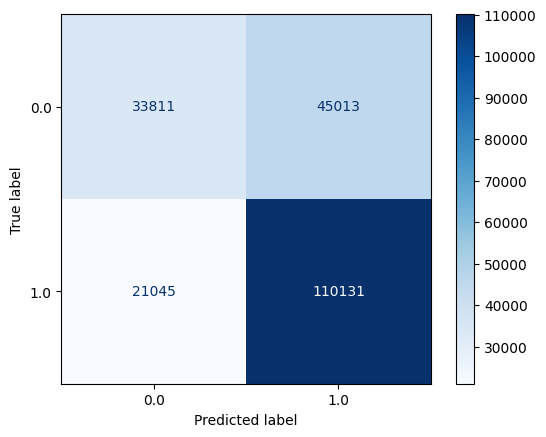

In [20]:
ConfusionMatrixDisplay.from_predictions(
    Y_test,
    Y_pred,
    cmap="Blues"
)
plt.show()